# Classical Heisenberg spin models with arbitrary exchange couplings
`classicalspin.SpinModel` describes classical spins, unit vectors $\vec S_i$ sitting on the sites
of a `Geometry`, each parametrized by a pair of angles $(\theta_i,\phi_i)$, with the energy

$$
E = \sum_{i,j} \vec S_i\cdot J_{ij}\cdot\vec S_j + \sum_i \vec B\cdot\vec S_i
$$

where $J_{ij}$ is a $3\times3$ exchange tensor and the sum runs over both orderings of every
pair, so that each bond enters twice. `sm.add_heisenberg(Jij=[J1,J2,...])` adds isotropic
couplings to first, second and further neighbors, the same way `g.get_hamiltonian(tij=...)`
reads a list of hoppings, and `Jm=[Jx,Jy,Jz]` makes them anisotropic (XXZ when $J_x=J_y$).
Any other form of coupling, dipolar, Dzyaloshinskii-Moriya, Ising or an arbitrary tensor, goes
in through `sm.add_tensor(fun)`, with ready-made functions in
`classicalspin.generating_functions()`, and `sm.add_field(v)` adds the Zeeman term, which
favors spins pointing against $\vec v$. The ground state is found by `sm.minimize_energy()`, a
gradient-based minimization started from `tries` random configurations, keeping the lowest one.
Only the $\Gamma$ point is used, meaning that the spin configuration repeats with the cell you
give it, so an order with several sublattices needs a supercell that holds all of them.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import classicalspin
import io, contextlib
np.random.seed(0) # reproducible random starting points

### The 120-degree state of the triangular antiferromagnet
On the triangular lattice an antiferromagnetic exchange cannot satisfy the three bonds of a
triangle at once. The compromise is the 120-degree state, three sublattices whose spins form
120 degrees with each other, so that $\vec S_i\cdot\vec S_j=-1/2$ on every bond and the energy
is $-3J$ per site with the double counting above. The $3\times3$ supercell is what allows it:
on the primitive cell the only configuration repeating at $\Gamma$ is the ferromagnetic one.
The left panel draws the spins in the plane they span, and the right panel is the matrix of
scalar products $\vec S_i\cdot\vec S_j$, which only takes the values $1$ and $-1/2$.

Minimum energy -27.000004
Minimum energy per spin -3.0000005
Energy per site: -3.0000005


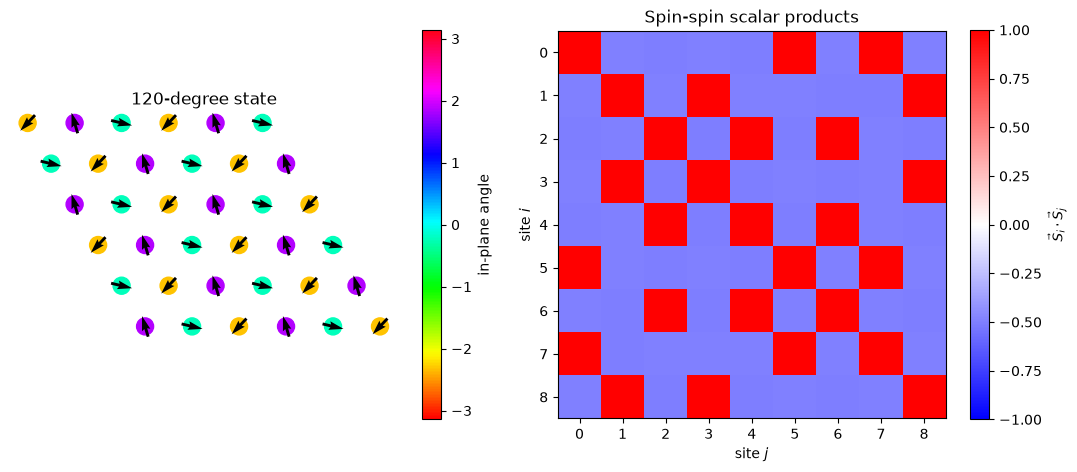

In [2]:
g = geometry.triangular_lattice() # geometrically frustrated lattice
g = g.get_supercell(3) # room for the three sublattices

sm = classicalspin.SpinModel(g) # classical spin model on this geometry
sm.add_heisenberg(Jij=[1.0]) # first-neighbor antiferromagnetic exchange
sm.minimize_energy(tries=5) # multistart local minimization

ms = sm.magnetization # unit vectors, one row per site
print("Energy per site:",sm.get_energy()/len(ms))

from pyqula.classicalspintk.align import most_perp_basis
ms2 = most_perp_basis(ms) # rotate to the plane the spins lie in
angle = np.arctan2(ms2[:,1],ms2[:,0]) # in-plane angle of each spin

fig,axs = plt.subplots(1,2,figsize=(11,4.5))
for R in [[0,0],[1,0],[0,1],[1,1]]: # draw a few copies of the supercell
    dr = R[0]*g.a1 + R[1]*g.a2
    sc = axs[0].scatter(g.x+dr[0],g.y+dr[1],c=angle,cmap="hsv",
                        vmin=-np.pi,vmax=np.pi,s=150)
    axs[0].quiver(g.x+dr[0],g.y+dr[1],ms2[:,0],ms2[:,1],pivot="middle")
plt.colorbar(sc,ax=axs[0],label="in-plane angle")
axs[0].set_aspect("equal") ; axs[0].axis("off")
axs[0].set_title("120-degree state")
im = axs[1].imshow(ms@ms.T,cmap="bwr",vmin=-1,vmax=1)
plt.colorbar(im,ax=axs[1],label="$\\vec S_i\\cdot\\vec S_j$")
axs[1].set_xlabel("site $j$") ; axs[1].set_ylabel("site $i$")
axs[1].set_title("Spin-spin scalar products")
plt.tight_layout()
plt.show()

### Anisotropy and a magnetic field: the spin-flop transition
Let us now combine an anisotropic exchange with a Zeeman field, on the square-lattice
antiferromagnet, and map the ground state over the plane of the anisotropy $J_z/J$ and the field
$B$ along $z$. With an easy-plane exchange ($J_z<J$) the spins lie in the plane and cant
towards the field continuously. With an easy-axis exchange ($J_z>J$) the antiferromagnet stays
along $z$, with zero magnetization, until the field reaches the spin-flop value, where the spins
jump into the plane perpendicular to the field and then cant as before, until they are fully
polarized. The left map is the magnetization along the field, the right one the staggered
magnetization along $z$, and the dashed lines are the classical spin-flop field
$B_{sf}=8\sqrt{J_z^2-J^2}$ and saturation field $B_s=8(J+J_z)$ of this model, in units where
every bond enters the energy twice.

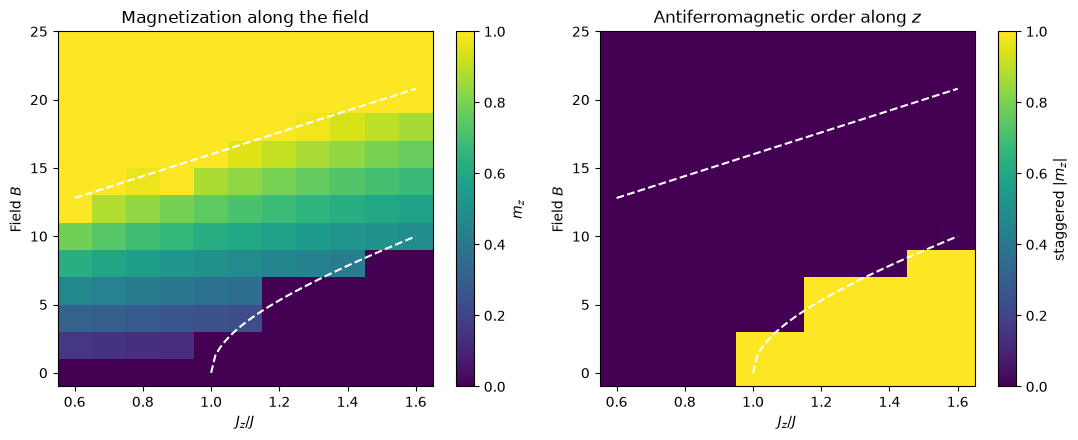

In [3]:
g = geometry.square_lattice() # bipartite lattice
g = g.get_supercell(2) # room for the two antiferromagnetic sublattices
stag = (-1.)**np.round(g.r[:,0]+g.r[:,1]) # +1 on one sublattice, -1 on the other

jzs = np.linspace(0.6,1.6,11) # exchange anisotropy Jz/J
bs = np.linspace(0.,24.,13) # field along z
mz = np.zeros((len(bs),len(jzs))) # magnetization along the field
sz = np.zeros((len(bs),len(jzs))) # staggered magnetization along z
for i,jz in enumerate(jzs):
    for j,b in enumerate(bs):
        sm = classicalspin.SpinModel(g)
        sm.add_heisenberg(Jij=[1.0],Jm=[1.,1.,jz]) # XXZ antiferromagnet
        sm.add_field([0.,0.,-b]) # Zeeman field favoring spins along +z
        with contextlib.redirect_stdout(io.StringIO()): # silence the energy of every run
            sm.minimize_energy(tries=2)
        m = sm.magnetization
        mz[j,i] = np.mean(m[:,2])
        sz[j,i] = np.abs(np.mean(stag*m[:,2]))

jj = np.linspace(1.,1.6,50)
fig,axs = plt.subplots(1,2,figsize=(11,4.5))
for ax,z,lab in zip(axs,[mz,sz],["$m_z$","staggered $|m_z|$"]):
    im = ax.pcolormesh(jzs,bs,z,shading="nearest",cmap="viridis",vmin=0,vmax=1)
    plt.colorbar(im,ax=ax,label=lab)
    ax.plot(jj,8*np.sqrt(jj**2-1),c="white",ls="--")
    ax.plot(jzs,8*(1+jzs),c="white",ls="--")
    ax.set_ylim(bs[0]-1,bs[-1]+1)
    ax.set_xlabel("$J_z/J$") ; ax.set_ylabel("Field $B$")
axs[0].set_title("Magnetization along the field")
axs[1].set_title("Antiferromagnetic order along $z$")
plt.tight_layout()
plt.show()